In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from core import *

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/var/folders/bs/pjtn_x6x0vlg303wglbxqthm0000gn/T/ipykernel_17931/2168479442.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load("/Users/danie

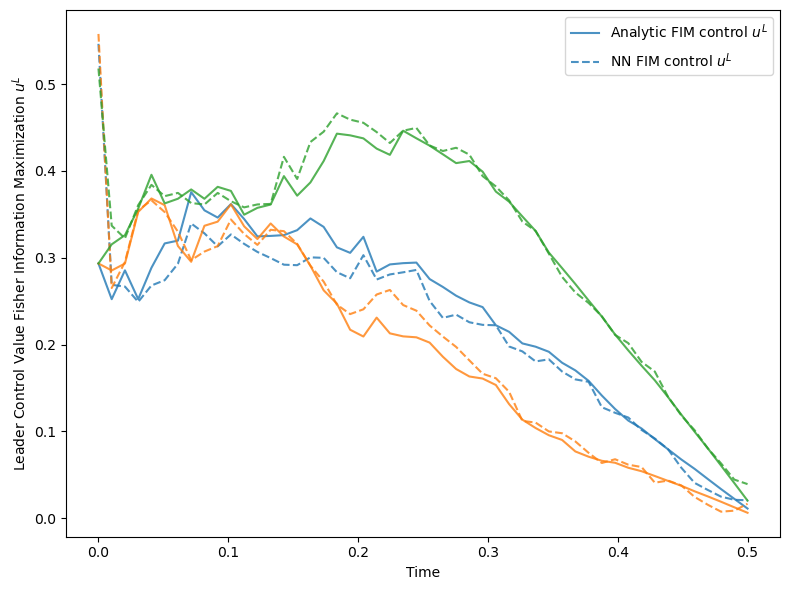

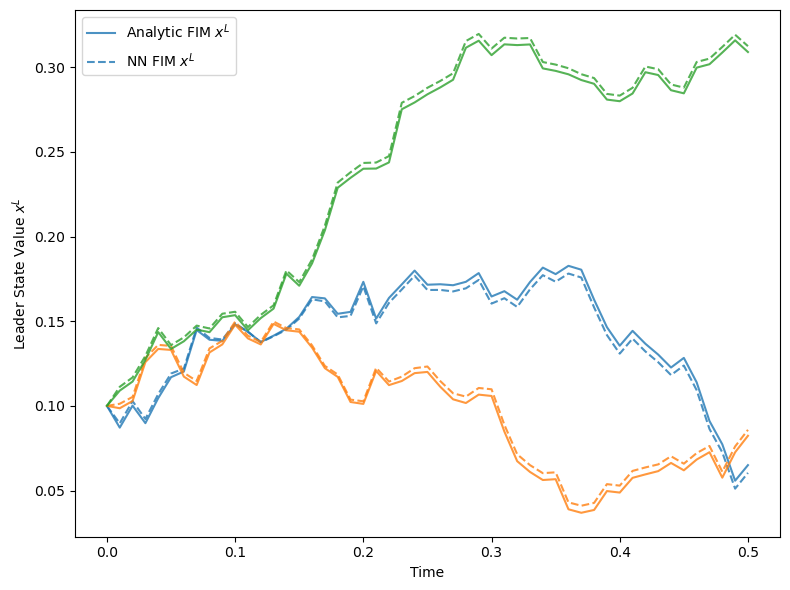

In [3]:
# plot learned vs analytic leader control and state trajectories

def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 0.01
params.lamb_L = 0.5
params.Q_L_T = 0.0
params.Q_L, params.Q_F = 0.0, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

leader_analytic = LeaderLBSolver(params, F)

net = DeepLSTMController(hidden=48, num_layers=2, dropout=0.1)
net.load_state_dict(torch.load("/Users/danielralston/Desktop/scrap/sym_notebooks/runs/leader_lstm_2025-06-01 12:01:30_50_5000_LB.pt", map_location=device))
net.to(device)
u_NN = make_nn_policy(net, params)

seed_plot = 123
batch_size_plot = 5000   # tune as desired
torch.manual_seed(seed_plot)
X_L_a_batch, U_L_a_batch = leader_analytic.simulate(batch=batch_size_plot, seed=seed_plot)
X_L_nn_batch, U_L_nn_batch = simulate_leader(u_NN, params, batch=batch_size_plot, seed=seed_plot)
X_L_nn_batch, U_L_nn_batch = X_L_nn_batch.detach(), U_L_nn_batch.detach()
time_grid_x = np.linspace(0, T, N+1)
time_grid_u = np.linspace(0, T, N)

good_samples = [1,7,9]
# good_samples = [1]
plt.figure(figsize=(8, 6))
for i, ind in enumerate(good_samples):
    c = f'C{i}'
    plt.plot(time_grid_u,
             U_L_a_batch[ind].cpu().numpy(),
             linestyle='-', color=c,
             alpha=0.8,
             label=f'Analytic FIM control $u^L$' if i == 0 else None)
    plt.plot(time_grid_u,   
             U_L_nn_batch[ind].cpu().numpy(),
             linestyle='--', color=c,
             alpha=0.8,
             label=f'NN FIM control $u^L$' if i == 0 else None)
plt.xlabel('Time')
plt.ylabel('Leader Control Value Fisher Information Maximization $u^L$')
# plt.suptitle(f'Sample Control Trajectory with $\lambda_L={lam_L}$')
# plt.title(f'Analytic cost of lower bound: {mc_lb:.3}, NN cost of lower bound: {nn_lb:.3}')
# plt.title(f'Sample Control Trajectory with $\lambda_L={lam_L}$, NN trained with exact cost')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
for i, ind in enumerate(good_samples):
    c = f'C{i}'
    plt.plot(time_grid_x,
             X_L_a_batch[ind].cpu().numpy(),
             linestyle='-', color=c,
             alpha=0.8,
             label=f'Analytic FIM $x^L$' if i == 0 else None)
    plt.plot(time_grid_x,
             X_L_nn_batch[ind].cpu().numpy(),
             linestyle='--', color=c,
             alpha=0.8,
             label=f'NN FIM $x^L$' if i == 0 else None)

plt.xlabel('Time')
plt.ylabel('Leader State Value $x^L$')
# plt.suptitle(f'Sample State Trajectories with $\lambda_L={lam_L}$')
# plt.title(f'Analytic cost of lower bound: {mc_lb:.3}, NN cost of lower bound: {nn_lb:.3}')
plt.legend()
plt.tight_layout()
plt.show()



/Users/danielralston/Desktop/Strategic-Inference-Stackleburg-Games/src/core.py:350: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_F[:, k] = torch.tensor((-params.B_F / params.R_F) * (2 * a_grid[k] * X_F[:, k] + b_grid[:, k]), device=params.device)


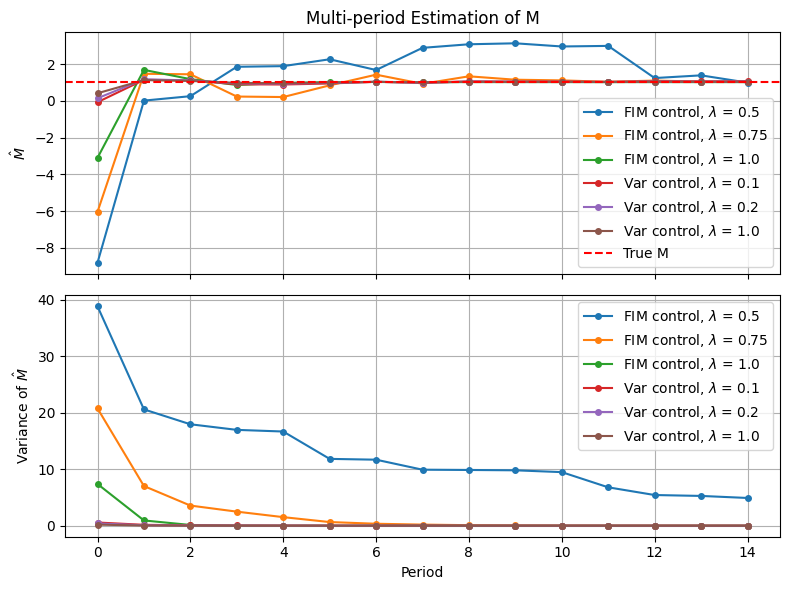

In [8]:
# multi-period estimation of system

def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.
# params.lamb_L = 1.0
params.Q_L_T = 1.0
params.Q_L, params.Q_F = 0.0, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

num_periods = 15
analy_lamb_L_vals = [0.5, 0.75, 1.0]
estM = {}
varM = {}
for val in analy_lamb_L_vals:
    params.lamb_L = val
    leader_analytic = LeaderLBSolver(params, F)
    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var = [0.0]
    for i in range(num_periods):
        params.X_L_0, params.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = leader_analytic.simulate(batch=1, seed=2*i)
        # X_L, U_L = simulate_leader(leader_controller, params, batch=1, seed=2*i)
        X_F, U_F = simulate_follower(X_L, params, batch=1, seed=2*i+1)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = int_trapz(f_grid * g * X_F, params.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(params.N)])
        denom = int_trapz((params.B_F**2/params.R_F) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        running_prec.append(running_prec[-1] + int_trapz(g**2, params.dt))
        new_M_est = (running_prec[-2]/ running_prec[-1]) * running_estM[-1] + (int_trapz(g**2, params.dt) / running_prec[-1]) * curr_M
        new_var_est = ((params.sig_F**2 * params.R_F**2)/(params.B_F**4)) * (1/running_prec[-1])
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()
    estM[f"FIM control, $\lambda$ = {val}"] = running_estM[1:]  # skip the initial 0
    varM[f"FIM control, $\lambda$ = {val}"] = running_var[1:]  # skip the initial 0
    # plt.plot(running_estM[1:])
    # plt.plot(running_var[1:])

net_weight_files = [
    (0.1, "/runs/leader_lstm_2025-06-06 14:04:16_0.1_500_exact.pt"),
    (0.2, "/runs/leader_lstm_2025-06-06 14:32:13_0.2_500_exact.pt"),
    (1.0, "/runs/leader_lstm_2025-06-06 10:02:21_1.0_500_exact.pt"),
]

for lam_exact_val, weight_file in net_weight_files:
    net = DeepLSTMController()
    net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    net.to(device)
    u_NN = make_nn_policy(net, params)
    curr_X_L_0, curr_X_F_0 = 0.1, 0.1
    running_prec = [0.0]
    running_estM = [0.0]
    running_var = [0.0]
    for i in range(num_periods):
        params.X_L_0, params.X_F_0 = curr_X_L_0, curr_X_F_0
        X_L, U_L = simulate_leader(u_NN, params, batch=1, seed=2*i)
        X_L, U_L = X_L.detach(), U_L.detach()
        X_F, U_F = simulate_follower(X_L, params, batch=1, seed=2*i+1)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = int_trapz(f_grid * g * X_F, params.dt)
        num_second = sum([g[0, j] * (X_F[0, j+1] - X_F[0, j]) for j in range(params.N)])
        denom = int_trapz((params.B_F**2/params.R_F) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        running_prec.append(running_prec[-1] + int_trapz(g**2, params.dt))
        new_M_est = (running_prec[-2]/ running_prec[-1]) * running_estM[-1] + (int_trapz(g**2, params.dt) / running_prec[-1]) * curr_M
        new_var_est = ((params.sig_F**2 * params.R_F**2)/(params.B_F**4)) * (1/running_prec[-1])
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
        curr_X_L_0 = X_L[0, -1].item()
        curr_X_F_0 = X_F[0, -1].item()
    estM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_estM[1:]  # skip the initial 0
    varM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_var[1:]  # skip the initial


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for lam_exact_val, running_estM in estM.items():
    ax1.plot(running_estM, label=f"{lam_exact_val}", marker='o', markersize=4)
for lam_exact_val, running_var in varM.items():
    ax2.plot(running_var, label=f"{lam_exact_val}", marker='o', markersize=4)
ax1.set_ylabel('$\hat{M}$')
ax2.set_ylabel('Variance of $\hat{M}$')
ax1.axhline(params.M_true, color='red', linestyle='--', label='True M')
ax1.set_title('Multi-period Estimation of M')
ax1.legend()
ax2.set_xlabel('Period')
ax2.legend()
ax2.grid(True)
ax1.grid(True)
plt.tight_layout()
plt.show()

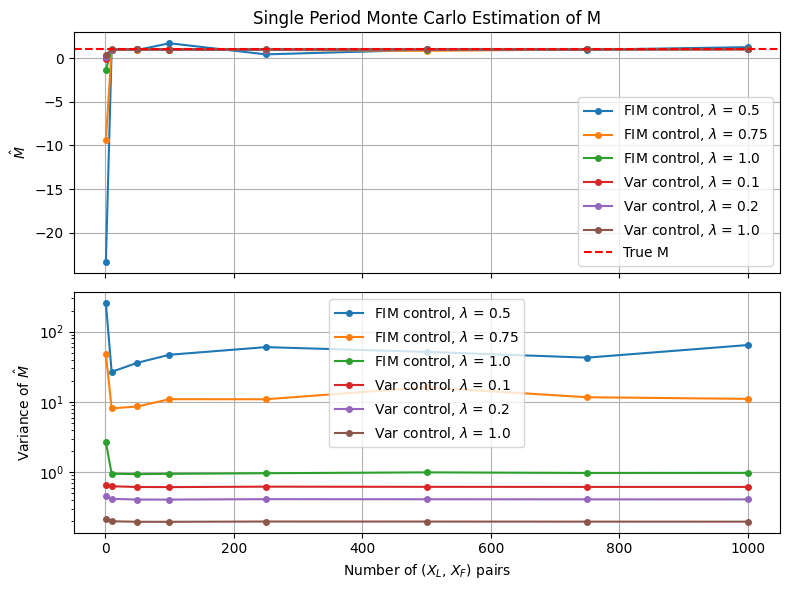

In [9]:
# single period monte carlo estimation of parameter M
def F(x):
    return 0.2 * torch.sin(2*np.pi * x / params.T)
    # return 0*torch.ones_like(x, device=params.device)

N = 50
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.
# params.lamb_L = 1.0
params.Q_L_T = 0.0
params.Q_L, params.Q_F = 0.0, 1.0
params.R_L, params.R_F = 1.0, 1.0
params.X_L_0, params.X_F_0 = 0.1, 0.1
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

num_single_periods = [1, 10, 50, 100, 250, 500, 750, 1000]
analy_lamb_L_vals = [0.5,0.75, 1.0]
estM = {}
varM = {}
for val in analy_lamb_L_vals:
    params.lamb_L = val
    leader_analytic = LeaderLBSolver(params, F)
    running_estM = [0.0]
    running_var = [0.0]
    for size in num_single_periods:
        X_L, U_L = leader_analytic.simulate(batch=size, seed=size)
        X_F, U_F = torch.zeros(X_L.shape, device=params.device), torch.zeros(U_L.shape, device=params.device)
        for i in range(size):
            X_F[i:i+1, :], U_F[i:i+1, :] = simulate_follower(X_L[i:i+1, :], params, batch=1, seed=(2*i+1)*size)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = torch.einsum('i,ji,ji->j', f_grid, g, X_F)* params.dt
        num_second = torch.sum(g[:,:-1] * (X_F[:, 1:] - X_F[:, :-1]), dim=1)
        denom = int_trapz((params.B_F**4/params.R_F**2) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        new_M_est = curr_M.mean()
        new_var_est = (params.sig_F**2/denom).mean()
        # new_var_est = curr_M.var()
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
    estM[f"FIM control, $\lambda$ = {val}"] = running_estM[1:]  # skip the initial 0
    varM[f"FIM control, $\lambda$ = {val}"] = running_var[1:]  # skip the initial 0
    # plt.plot(running_estM[1:])
    # plt.plot(running_var[1:])
    
net_weight_files = [
    (0.1, "/runs/leader_lstm_2025-06-06 14:04:16_0.1_500_exact.pt"),
    (0.2, "/runs/leader_lstm_2025-06-06 14:32:13_0.2_500_exact.pt"),
    (1.0, "/runs/leader_lstm_2025-06-06 10:02:21_1.0_500_exact.pt"),
]

for lam_exact_val, weight_file in net_weight_files:
    net = DeepLSTMController()
    net.load_state_dict(torch.load(os.getcwd() + weight_file, map_location=device))
    net.to(device)
    u_NN = make_nn_policy(net, params)
    running_estM = [0.0]
    running_var = [0.0]
    for size in num_single_periods:
        X_L, U_L = simulate_leader(u_NN, params, batch=size, seed=size)
        X_L, U_L = X_L.detach(), U_L.detach()
        X_F, U_F = torch.zeros(X_L.shape, device=params.device), torch.zeros(U_L.shape, device=params.device)
        for i in range(size):
            X_F[i:i+1, :], U_F[i:i+1, :] = simulate_follower(X_L[i:i+1, :], params, batch=1, seed=(2*i+1)*size)
        a_grid = compute_a_grid(params)
        f_grid = compute_f_grid(params)
        g = compute_b_grid(params, a_grid, X_L) / params.M_true
        num_first = torch.einsum('i,ji,ji->j', f_grid, g, X_F)* params.dt
        num_second = torch.sum(g[:,:-1] * (X_F[:, 1:] - X_F[:, :-1]), dim=1)
        denom = int_trapz((params.B_F**4/params.R_F**2) * (g**2), params.dt)
        curr_M = (num_first - num_second) / denom
        new_M_est = curr_M.mean()
        new_var_est = (params.sig_F**2 /denom).mean()
        # new_var_est = curr_M.var()
        if torch.isnan(new_M_est):
            new_M_est = running_estM[-1]
        if torch.isnan(new_var_est):
            new_var_est = running_var[-1]
        running_estM.append(new_M_est)
        running_var.append(new_var_est)
    estM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_estM[1:]  # skip the initial 0
    varM[f"Var control, $\lambda$ = {lam_exact_val}"] = running_var[1:]  # skip the initial
    # plt.plot(running_estM[1:])
    # plt.plot(running_var[1:])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for lam_exact_val, running_estM in estM.items():
    ax1.plot(num_single_periods, running_estM, label=f"{lam_exact_val}", marker='o', markersize=4)
for lam_exact_val, running_var in varM.items():
    ax2.plot(num_single_periods, running_var, label=f"{lam_exact_val}", marker='o', markersize=4)
ax1.set_ylabel('$\hat{M}$')
ax2.set_ylabel('Variance of $\hat{M}$')
ax2.set_yscale('log')
ax1.axhline(params.M_true, color='red', linestyle='--', label='True M')
ax1.set_title('Single Period Monte Carlo Estimation of M')
ax1.legend()
ax2.set_xlabel('Number of ($X_L$, $X_F$) pairs')
ax2.legend()
ax2.grid(True)
ax1.grid(True)
plt.tight_layout()
plt.show()

/Users/danielralston/Desktop/Strategic-Inference-Stackleburg-Games/src/core.py:259: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  U_F[:, k] = torch.tensor((-params.B_F / params.R_F) * (2 * a_grid[k] * X_F[:, k] + b_grid[:, k]), device=params.device)


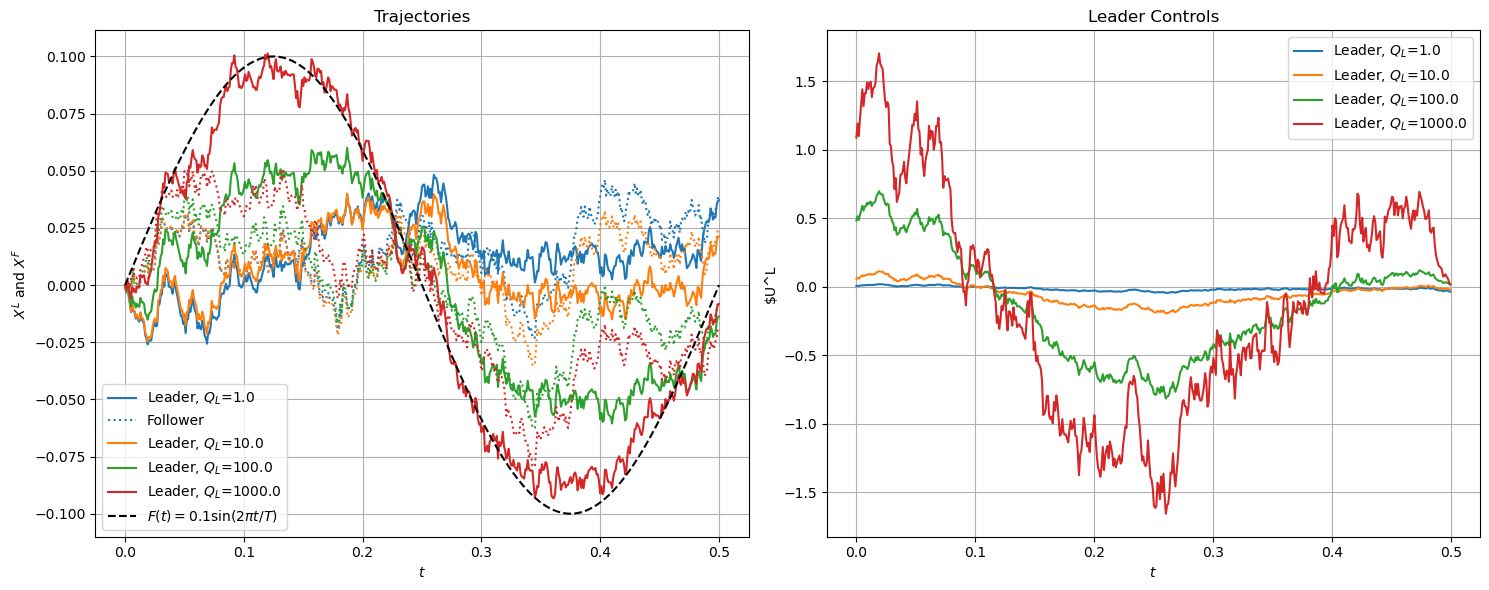

In [4]:
# show tradeoff between primary and info tasks
def F(x):
    return 0.1 * torch.sin(2*np.pi * x / params.T)

N = 500
T = 0.5

params = SystemParams()
params.A_L, params.A_F = -1.0, -1.0
params.B_L, params.B_F = 1.0, 1.0
params.sig_L, params.sig_F = 0.1, 0.1
params.M_true = 1.0
params.lamb_F = 1.0
params.lamb_L = 0.0
params.Q_L_T = 1.0
params.Q_L, params.Q_F = None, 1.0
params.R_L, params.R_F = 1.0, 0.01
params.X_L_0, params.X_F_0 = 0.0, 0.0
params.T, params.N = T, N
params.device = device
params.time_grid = torch.linspace(0, params.T, params.N + 1, device=params.device)
params.dt = params.T / params.N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for i,Q_L in enumerate([1.,10.,100.,1000.]):
    params.Q_L = Q_L
    leader_analytic = LeaderLBSolver(params, F)
    X_L, U_L = leader_analytic.simulate(batch=1, seed=2)
    X_F, U_F = simulate_follower(X_L, params, batch=1, seed=3)
    ax1.plot(params.time_grid, X_L[0, :].cpu().numpy(), label=f'Leader, $Q_L$={Q_L}', color=f'C{i}')
    if i == 0:
        ax1.plot(params.time_grid, X_F[0, :].cpu().numpy(), label='Follower', color=f'C{i}', linestyle=':')
    else:
        ax1.plot(params.time_grid, X_F[0, :].cpu().numpy(), color=f'C{i}', linestyle=':')
    ax2.plot(params.time_grid[:-1], U_L[0, :].cpu().numpy(), label=f'Leader, $Q_L$={Q_L}', color=f'C{i}')

ax1.plot(params.time_grid, F(params.time_grid).cpu().numpy(), 'k--', label='$F(t)=0.1\sin(2\pi t / T)$')
ax1.set_xlabel('$t$')
ax1.set_ylabel('$X^L$ and $X^F$')
ax1.set_title('Trajectories')
ax1.legend()
ax1.grid()

ax2.set_xlabel('$t$')
ax2.set_ylabel('$U^L')
ax2.set_title('Leader Controls')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

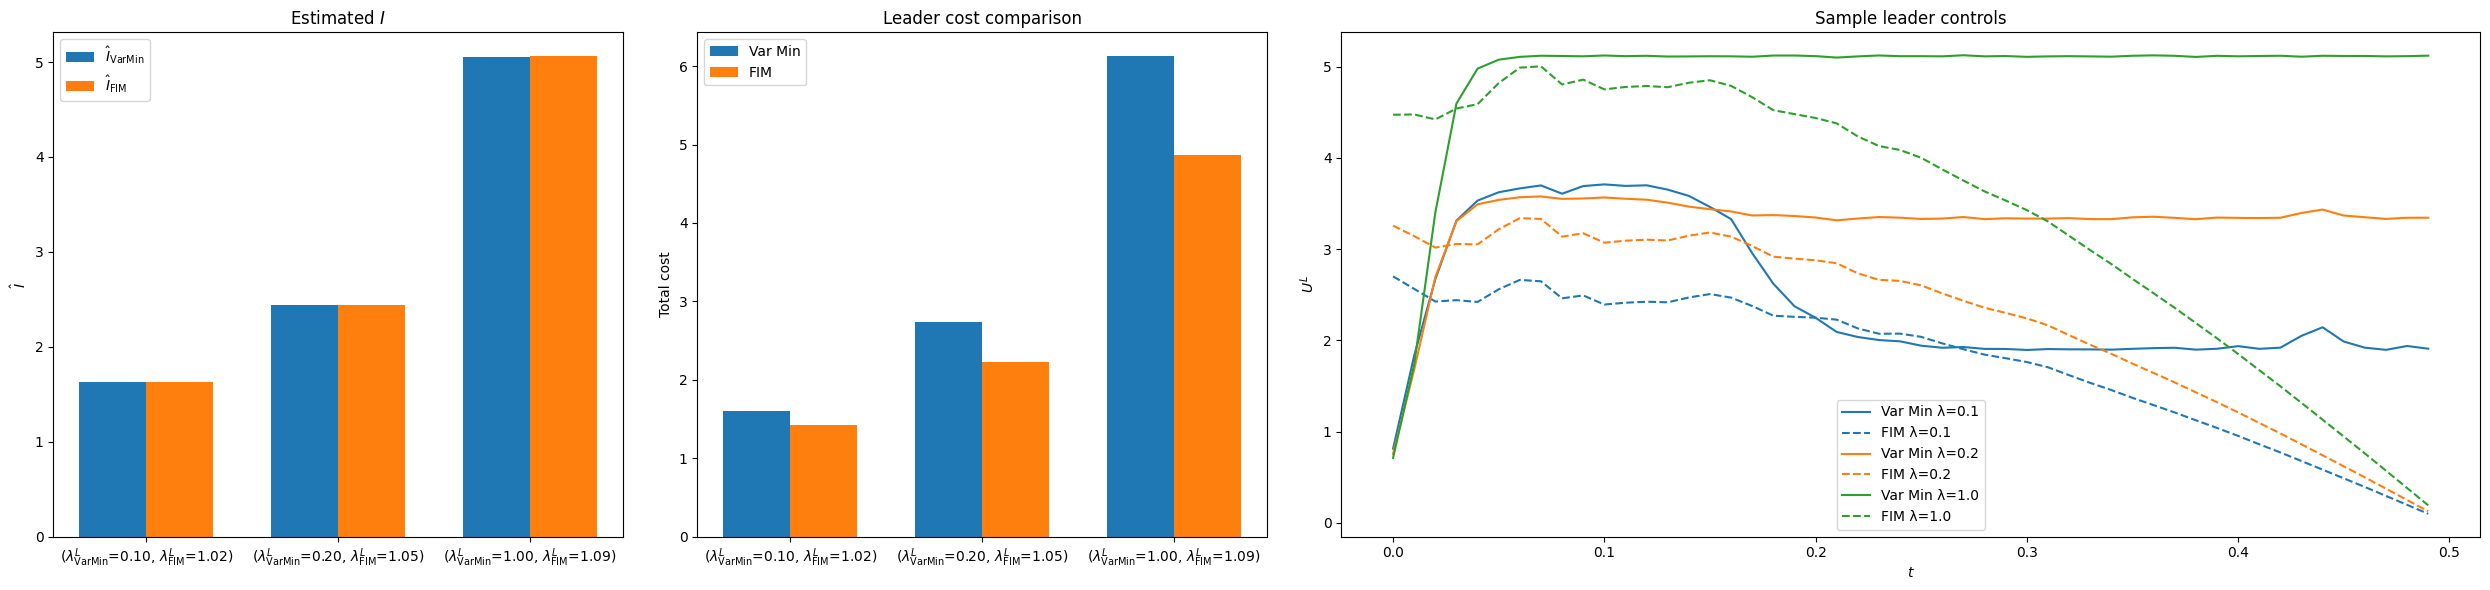

In [11]:

def F(x):
    # return torch.sin(2*np.pi * x / T)
    return 0 * torch.ones_like(x)

T, N = 0.5, 50

# note, R_F = 1.0, Q_F = 2.0, Q_L = 0.0, R_L = 1.
lamb_pairs = [
    (0.1, 1.025),
    (0.2, 1.052),
    (1.0, 1.092),
]
net_weight_files = [
    "/runs/leader_lstm_2025-06-06 14:04:16_0.1_500_exact.pt",
    "/runs/leader_lstm_2025-06-06 14:32:13_0.2_500_exact.pt",
    "/runs/leader_lstm_2025-06-06 10:02:21_1.0_500_exact.pt",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lambda_exact_vals               = []   # for x‑tick labels
lambda_lb_vals                  = []   # for x‑tick labels
estI_exact_vals, estI_lb_vals   = [], []
exact_cost_vals, lb_cost_vals   = [], []

fig, axs = plt.subplots(1, 3, figsize=(25, 6),
                        gridspec_kw={'width_ratios': [1, 1, 2]})
ax_estI, ax_cost, ax_ctrl = axs

for i, (weight_file, lamb_L_exact, lamb_L_LB) in enumerate(
        zip(net_weight_files, *zip(*lamb_pairs))):

    params_exact = SystemParams()
    params_exact.A_L, params_exact.A_F = -1.0, -1.0
    params_exact.B_L, params_exact.B_F = 1.0, 1.0
    params_exact.sig_L, params_exact.sig_F = 0.1, 0.1
    params_exact.M_true, params_exact.lamb_F = 1.0, 1.0
    params_exact.lamb_L = lamb_L_exact
    params_exact.Q_L_T, params_exact.Q_L, params_exact.Q_F = 0.0, 0.0, 1.0
    params_exact.R_L, params_exact.R_F = 1.0, 1.0
    params_exact.X_L_0, params_exact.X_F_0 = 0.1, 0.1
    params_exact.T, params_exact.N = T, N
    params_exact.device = device
    params_exact.time_grid = torch.linspace(0, T, N + 1, device=device)
    params_exact.dt = T / N

    exact_net = DeepLSTMController()
    exact_net.load_state_dict(torch.load(os.getcwd() + weight_file,
                                         map_location=device))
    exact_net.to(device)

    X_L_exact, U_L_exact = simulate_leader(
        make_nn_policy(exact_net, params_exact),
        params_exact, batch=10000, seed=0
    )
    est_I = estimate_I_batch(X_L_exact, params_exact)

    # lamb_L_LB = (lamb_L_exact / (est_I ** 2))

    params_LB = SystemParams()
    # copy everything, then overwrite lamb_L
    for attr in vars(params_exact):
        setattr(params_LB, attr, getattr(params_exact, attr))
    params_LB.lamb_L = lamb_L_LB

    leader_lb = LeaderLBSolver(params_LB, F)
    X_L_lb, U_L_lb = leader_lb.simulate(batch=10000, seed=0)
    est_I_lb = estimate_I_batch(X_L_lb, params_LB)

    # exact_cost = exact_leader_total_cost(X_L_exact, U_L_exact, params_exact, F)
    # params_LB.lamb_L = lamb_L_exact
    # lb_cost = exact_leader_total_cost(X_L_lb, U_L_lb, params_exact, F)
    exact_cost = (1/2)*int_trapz(U_L_exact**2, params_exact.dt).mean()
    lb_cost = (1/2)*int_trapz(U_L_lb**2, params_LB.dt).mean()

    lambda_exact_vals.append(float(lamb_L_exact))
    lambda_lb_vals.append(float(lamb_L_LB))
    estI_exact_vals.append(float(est_I))
    estI_lb_vals.append(float(est_I_lb))
    exact_cost_vals .append(float(exact_cost))
    lb_cost_vals.append(float(lb_cost))

    ax_ctrl.plot(params_exact.time_grid[:-1],
                 U_L_exact[0].detach().cpu().numpy(),
                 label=f'Var Min λ={lamb_L_exact}',
                 color=f'C{i}', linestyle='-')
    ax_ctrl.plot(params_LB.time_grid[:-1],
                 U_L_lb[0].detach().cpu().numpy(),
                 label=f'FIM λ={lamb_L_exact}',
                 color=f'C{i}', linestyle='--')

x = np.arange(len(lambda_exact_vals))
width = 0.35

ax_estI.bar(x - width/2, estI_exact_vals, width,
            color='tab:blue',   label=r'$\hat I_{\mathrm{Var Min}}$')
ax_estI.bar(x + width/2, estI_lb_vals,    width,
            color='tab:orange', label=r'$\hat I_{\mathrm{FIM}}$')

ax_estI.set_xticks(x)
ax_estI.set_xticklabels([r"($\lambda_{\mathrm{Var Min}}^L$"+f"={v:.2f}, "+ r"$\lambda_{\mathrm{FIM}}^L$"+f"={u:.2f})" for v,u in zip(lambda_exact_vals, lambda_lb_vals)])
ax_estI.set_ylabel(r'$\hat I$')
ax_estI.set_title(r'Estimated $I$')
ax_estI.legend()

ax_cost.bar(x - width/2, exact_cost_vals, width, label='Var Min')
ax_cost.bar(x + width/2, lb_cost_vals,    width, label='FIM')

ax_cost.set_xticks(x)
ax_cost.set_xticklabels([r"($\lambda_{\mathrm{Var Min}}^L$"+f"={v:.2f}, "+ r"$\lambda_{\mathrm{FIM}}^L$"+f"={u:.2f})" for v,u in zip(lambda_exact_vals, lambda_lb_vals)])
ax_cost.set_ylabel('Total cost')

ax_cost.set_title('Leader cost comparison')
ax_cost.legend()
ax_ctrl.set_xlabel('$t$')
ax_ctrl.set_ylabel('$U^L$')
ax_ctrl.set_title('Sample leader controls')
ax_ctrl.legend()

plt.tight_layout()
plt.show()
